In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

digits = load_digits()
X = digits.images.astype("float32") / 16.0
y = digits.target.astype("int64")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train[:, None, :, :]), torch.tensor(y_train)),
    batch_size=128,
    shuffle=True,
)
test_x = torch.tensor(X_test[:, None, :, :], device=device)
test_y = torch.tensor(y_test, device=device)
prompts = [f"a handwritten digit {i}" for i in range(10)]
prompts

Device: cpu


/home/durgaumadev/security-for-data-science-lab/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


['a handwritten digit 0',
 'a handwritten digit 1',
 'a handwritten digit 2',
 'a handwritten digit 3',
 'a handwritten digit 4',
 'a handwritten digit 5',
 'a handwritten digit 6',
 'a handwritten digit 7',
 'a handwritten digit 8',
 'a handwritten digit 9']

In [3]:
class MiniCLIP(nn.Module):
    def __init__(self, embed_dim=32, num_classes=10):
        super().__init__()
        self.image_encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, embed_dim),
        )
        self.text_encoder = nn.Embedding(num_classes, embed_dim)
        self.logit_scale = nn.Parameter(torch.tensor(2.0))

    def forward(self, images):
        image_features = F.normalize(self.image_encoder(images), dim=-1)
        text_ids = torch.arange(10, device=images.device)
        text_features = F.normalize(self.text_encoder(text_ids), dim=-1)
        logits = self.logit_scale.exp() * image_features @ text_features.T
        return logits

model = MiniCLIP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(8):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        loss = F.cross_entropy(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
    print(f"epoch {epoch + 1}: loss={total_loss / len(train_loader.dataset):.4f}")

epoch 1: loss=2.2703
epoch 2: loss=1.4609
epoch 3: loss=0.5398
epoch 4: loss=0.3390
epoch 5: loss=0.2489


epoch 6: loss=0.1714
epoch 7: loss=0.1279
epoch 8: loss=0.1086


Zero-shot-style digit accuracy: 0.971


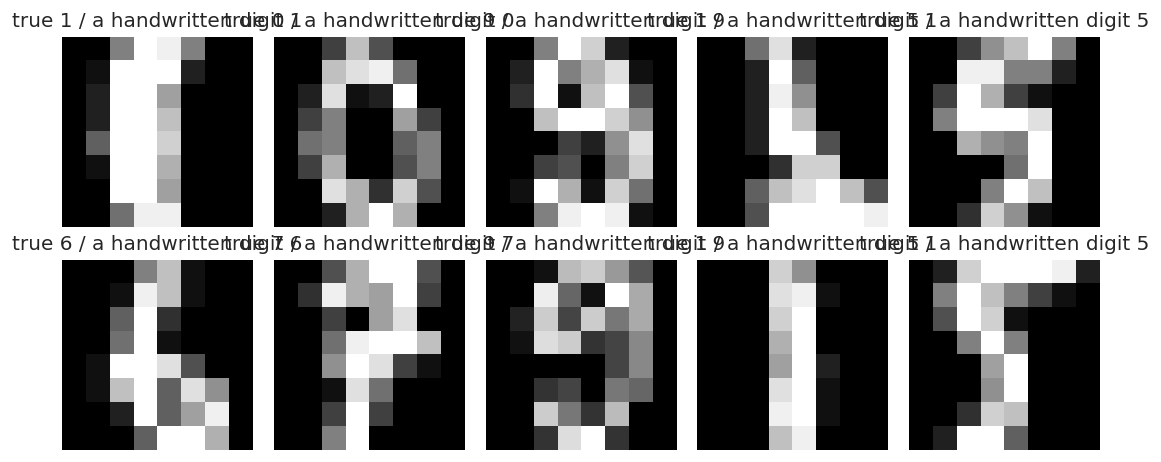

In [4]:
model.eval()
with torch.no_grad():
    logits = model(test_x)
    pred = logits.argmax(dim=1)
    accuracy = (pred == test_y).float().mean().item()
print(f"Zero-shot-style digit accuracy: {accuracy:.3f}")

fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for ax, image, true_label, pred_label in zip(axes.ravel(), X_test[:10], y_test[:10], pred[:10].cpu().numpy()):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"true {true_label} / {prompts[pred_label]}")
    ax.axis("off")
plt.tight_layout()
plt.show()